# 01 — Data Collection
## SME AutoFlow: n8n Workflow Template Dataset

**Author:** Hammad Ali (FA23-BCS-007)  
**Project:** SME AutoFlow — GDGoC AI/ML Fellowship Final Project

---

### Data Source

The dataset is built from the **n8n public template API**:

```
https://api.n8n.io/api/templates/search?page=1&rows=50
```

n8n is an open-source workflow automation tool. Their public API exposes ~2000+ community-contributed workflow templates. Each template contains:

| Field | Description |
|---|---|
| `id` | Unique template identifier |
| `name` | Human-readable template name |
| `description` | Detailed description of the workflow |
| `nodes` | List of n8n node types used (e.g. `n8n-nodes-base.gmail`) |
| `categories` / `tags` | Category labels assigned by the community |

We fetch **pages 1–20** (50 per page) to collect **~1,000 templates**, which form the basis for training our ML models.

In [1]:
import sys, os
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we can import from the data/ directory
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw_templates'

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')

Project root: C:\Users\User\OneDrive\Desktop\SME_WorkFlow_Final_Project
Data dir:     C:\Users\User\OneDrive\Desktop\SME_WorkFlow_Final_Project\data


## Step 1: Fetch Raw Templates

The script `data/fetch_templates.py` fetches all templates from the n8n API and saves each one as an individual JSON file in `data/raw_templates/`.

It includes:
- Retry logic with exponential backoff
- Deduplication by template ID
- Progress reporting every 5 pages

In [2]:
# Check if raw templates already exist (avoid re-fetching)
raw_files = list(RAW_DIR.glob('*.json'))
print(f'Raw template files found: {len(raw_files)}')

if len(raw_files) == 0:
    print('No templates found — running fetch_templates.py ...')
    exec(open(DATA_DIR / 'fetch_templates.py').read())
    raw_files = list(RAW_DIR.glob('*.json'))
    print(f'After fetch: {len(raw_files)} files')
else:
    print('Templates already fetched. Skipping download.')

Raw template files found: 1000
Templates already fetched. Skipping download.


In [3]:
# Preview a single raw template
sample_file = sorted(raw_files)[0]
with open(sample_file, 'r', encoding='utf-8') as f:
    sample = json.load(f)

print(f'Sample file: {sample_file.name}')
print(f'Keys: {list(sample.keys())}\n')
print(json.dumps(sample, indent=2, ensure_ascii=False)[:1000])

Sample file: template_10000.json
Keys: ['id', 'name', 'description', 'nodes', 'tags']

{
  "id": 10000,
  "name": "Auto-Create TikTok Videos with VEED.io AI Avatars, ElevenLabs & GPT-4",
  "description": "💥 Viral TikTok Video Machine: Auto-Create Videos with Your AI Avatar\n\n🎯 Who is this for?\nThis workflow is for content creators, marketers, and agencies who want to use Veed.io’s AI avatar technology to produce short, engaging TikTok videos automatically.  \nIt’s ideal for creators who want to appear on camera without recording themselves, and for teams managing multiple brands who need to generate videos at scale.\n\n⚙️ What problem this workflow solves\nManually creating videos for TikTok can take hours — finding trends, writing scripts, recording, and editing.  \nBy combining Veed.io, ElevenLabs, and GPT-4, this workflow transforms a simple Telegram input into a ready-to-post TikTok video featuring your AI avatar powered by Veed.io — speaking naturally with your cloned voice.\n\n

## Step 2: Build Labelled Dataset

The script `data/build_dataset.py` reads all raw template JSONs and:

1. Extracts `description` and `nodes` from each template
2. Auto-labels each template with an **intent category** based on which n8n nodes are present
3. Outputs two files:
   - `data/processed_templates.json` — full records with raw JSON
   - `data/labeled_dataset.csv` — slim CSV for ML training

### Intent Labelling Rules

| Nodes containing... | Intent Label |
|---|---|
| gmail, email, smtp, imap | `email_automation` |
| slack, telegram, discord | `team_communication` |
| webhook, http, rest, graphql | `data_sync` |
| postgres, mysql, mongodb, supabase | `database_ops` |
| twitter, instagram, linkedin | `social_media` |
| google_sheets, notion, trello | `productivity` |
| stripe, shopify, woocommerce | `ecommerce` |
| openai, gemini, huggingface | `ai_tasks` |
| schedule, cron | `scheduling` |
| *(anything else)* | `general` |

In [4]:
# Check if labelled dataset exists
csv_path = DATA_DIR / 'labeled_dataset.csv'

if not csv_path.exists():
    print('Dataset not found — running build_dataset.py ...')
    exec(open(DATA_DIR / 'build_dataset.py').read())
else:
    print(f'Labelled dataset already exists at {csv_path.name}')

Labelled dataset already exists at labeled_dataset.csv


## Step 3: Explore the Dataset

In [5]:
# Load the labelled dataset
df = pd.read_csv(DATA_DIR / 'labeled_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}\n')
df.head(10)

Dataset shape: (1000, 3)
Columns: ['description', 'nodes', 'intent']
Missing values:
description    0
nodes          6
intent         0
dtype: int64



,description,nodes,intent
0,💥 Viral TikTok Video Machine: Auto-Create Vide...,"n8n-nodes-base.googleSheets,n8n-nodes-base.htt...",team_communication
1,🎬 TikTok Video Downloader (No Watermark) - Tel...,"n8n-nodes-base.httpRequest,n8n-nodes-base.tele...",team_communication
2,Shopify Digital Product Automation\n(from just...,"n8n-nodes-base.airtable,n8n-nodes-base.httpReq...",data_sync
3,🧠 About this workflow\nThis workflow automatic...,"n8n-nodes-base.googleSheets,n8n-nodes-base.htt...",data_sync
4,PDF Invoice Extractor (AI)\n\nEnd-to-end pipel...,"n8n-nodes-base.httpRequest,n8n-nodes-base.goog...",data_sync
5,Overview \nThis project is an AI-powered What...,"n8n-nodes-base.httpRequest,n8n-nodes-base.what...",data_sync
6,LinkedIn URL → Scrape → Match → Screen → Decid...,"n8n-nodes-base.googleSheets,n8n-nodes-base.htt...",team_communication
7,🚀 Channable + Google Ads + Relevance AI: Scala...,"n8n-nodes-base.googleSheets,n8n-nodes-base.htt...",team_communication
8,🧠 Google Ads Monthly Performance Optimization ...,"n8n-nodes-base.googleSheets,n8n-nodes-base.htt...",team_communication
9,🛍️ Google Shopping Feed Optimization with Chan...,"n8n-nodes-base.httpRequest,n8n-nodes-base.slac...",team_communication


In [6]:
# Intent category distribution
intent_counts = df['intent'].value_counts()
print('Intent Category Breakdown:')
print(intent_counts)
print(f'\nTotal samples: {len(df)}')

Intent Category Breakdown:
intent
data_sync             327
email_automation      254
team_communication    208
ai_tasks              119
general                60
database_ops           25
social_media            4
productivity            2
ecommerce               1
Name: count, dtype: int64

Total samples: 1000


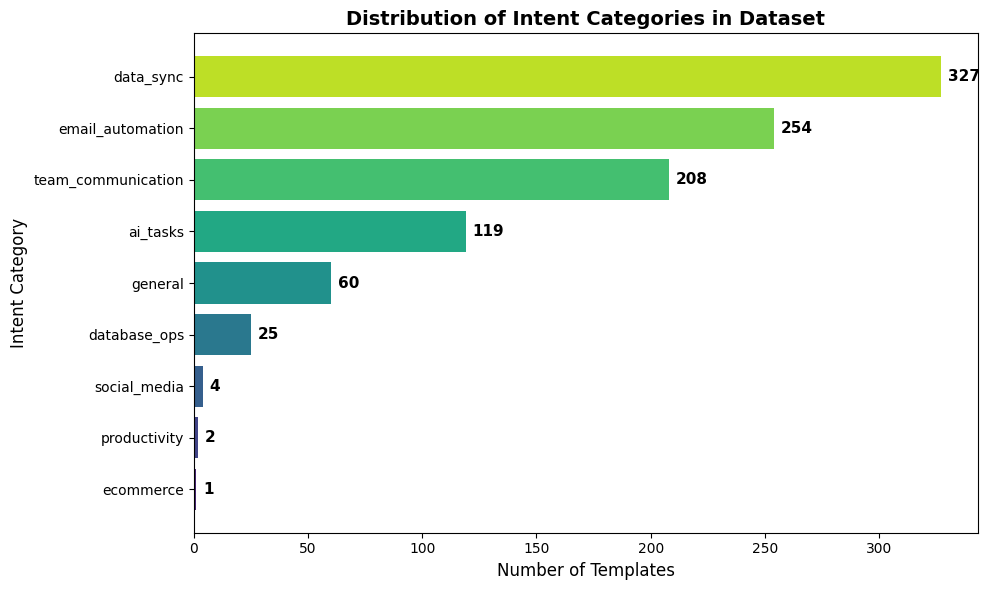

Chart saved to docs/intent_distribution.png


In [7]:
# Visualise intent distribution
plt.figure(figsize=(10, 6))
colors = sns.color_palette('viridis', n_colors=len(intent_counts))
bars = plt.barh(intent_counts.index[::-1], intent_counts.values[::-1], color=colors)
plt.xlabel('Number of Templates', fontsize=12)
plt.ylabel('Intent Category', fontsize=12)
plt.title('Distribution of Intent Categories in Dataset', fontsize=14, fontweight='bold')

# Add count labels on bars
for bar, count in zip(bars, intent_counts.values[::-1]):
    plt.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / 'docs' / 'intent_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to docs/intent_distribution.png')

In [8]:
# Quick stats on descriptions and nodes
df['desc_length'] = df['description'].str.len()
df['node_count'] = df['nodes'].fillna('').apply(lambda x: len([n for n in str(x).split(',') if n.strip()]))

print('Description length stats:')
print(df['desc_length'].describe().round(0))
print(f'\nNodes per template stats:')
print(df['node_count'].describe().round(1))

Description length stats:
count     1000.0
mean      3044.0
std       2015.0
min        294.0
25%       1797.0
50%       2560.0
75%       3660.0
max      17091.0
Name: desc_length, dtype: float64

Nodes per template stats:
count    1000.0
mean        5.1
std         2.5
min         0.0
25%         3.0
50%         5.0
75%         6.0
max        18.0
Name: node_count, dtype: float64


## Summary

### What the dataset contains:

| Property | Value |
|---|---|
| **Source** | n8n public template API |
| **Total templates** | ~1,000 |
| **Features** | `description` (text), `nodes` (comma-separated list) |
| **Target variable** | `intent` (auto-labelled from node types) |
| **Number of classes** | 9 intent categories |
| **Output files** | `labeled_dataset.csv`, `processed_templates.json` |

### Key observations:

- The dataset is **imbalanced** — `data_sync` and `email_automation` dominate, while `ecommerce`, `productivity`, and `social_media` have very few samples.
- Descriptions vary significantly in length, from short one-liners to detailed multi-paragraph explanations.
- Most templates use 3–8 nodes.

### Next steps:

1. **EDA notebook** (`02_eda.ipynb`) — deeper exploration and visualisation
2. **Intent Classifier** (`03_intent_classifier.ipynb`) — train Model 1
3. **Node Recommender** (`04_node_recommender.ipynb`) — train Model 2